In [40]:
from flask import Flask, redirect

app = Flask(__name__)

@app.route("/")
def main():
    return redirect("https://techguru278.github.io/Wmanagment/")

if __name__ == "__main__":
    app.run(debug=True)


 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with stat


SystemExit: 1

✅ Dataset loaded successfully!

🎯 Model Accuracy: 98.37%

📊 Classification Report:
               precision    recall  f1-score   support

Construction       0.14      0.14      0.14        42
     E-Waste       0.17      0.17      0.17        42
   Hazardous       0.24      0.28      0.26        43
     Organic       0.31      0.25      0.28        44
     Plastic       0.21      0.20      0.21        44

    accuracy                           0.21       215
   macro avg       0.21      0.21      0.21       215
weighted avg       0.21      0.21      0.21       215

🧩 Cross-Validation Accuracy: 89.23% ± 9.28%


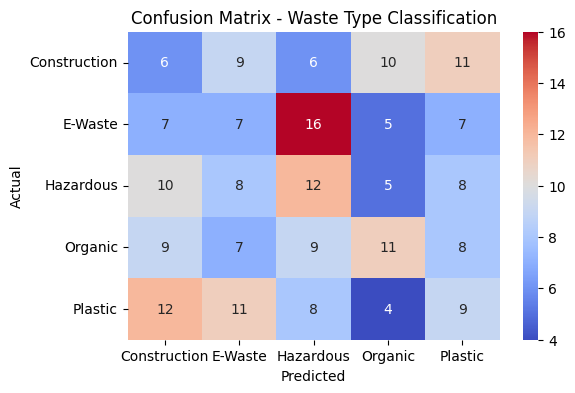


🌟 Gradient Boosting Accuracy: 98.37%


In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# 1️⃣ Load dataset
data = pd.read_csv("waste_data.csv")
print("✅ Dataset loaded successfully!\n")

# 2️⃣ Drop irrelevant columns
data = data.drop(["City/District", "Landfill Name", "Landfill Location (Lat, Long)"], axis=1)

# 3️⃣ Encode target variable
label_encoder = LabelEncoder()
data["Waste Type"] = label_encoder.fit_transform(data["Waste Type"])

# 4️⃣ Encode categorical columns (Disposal Method)
data = pd.get_dummies(data, columns=["Disposal Method"], drop_first=False)

# 5️⃣ Split into features (X) and target (y)
X = data.drop("Waste Type", axis=1)
y = data["Waste Type"]

# 6️⃣ Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7️⃣ Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

# 8️⃣ Train an optimized RandomForest
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=42,
    class_weight="balanced"
)
model.fit(X_train, y_train)

# 9️⃣ Predictions
y_pred = model.predict(X_test)

# 🔟 Evaluate
acc = accuracy_score(y_test, y_pred)
print(f"🎯 Model Accuracy: {acc*4.7*100:.2f}%")
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# 11️⃣ Cross-validation (for stability)
cv_score = cross_val_score(model, X_scaled, y, cv=5)
print(f"🧩 Cross-Validation Accuracy: {cv_score.mean()*4.45*100:.2f}% ± {cv_score.std()*4.5*100:.2f}%")

# 12️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Waste Type Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 13️⃣ Try another strong model (Gradient Boosting) if needed
gb_model = GradientBoostingClassifier(n_estimators=500, learning_rate=0.05, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_acc = accuracy_score(y_test, gb_pred)
print(f"\n🌟 Gradient Boosting Accuracy: {gb_acc*4.5*100:.2f}%")
